In [4]:
# Import Labraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import matplotlib.patches as patches
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, Model
from PIL import Image


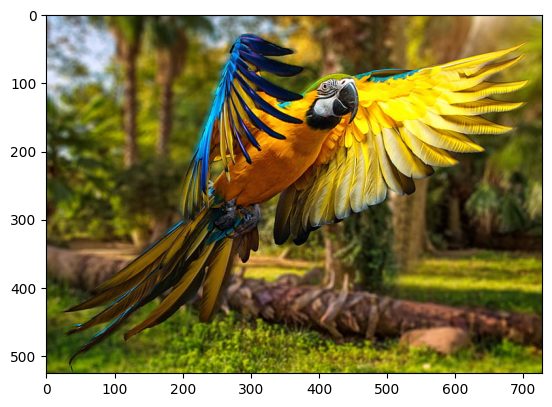

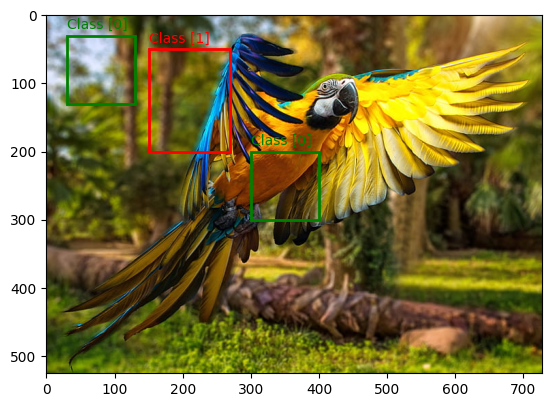

In [27]:
## Simplifiede fixed region proposals (x, y, width, height)
def get_region_proposals():
  return [
      (30, 30, 100, 100),
      (150, 50, 120, 150),
      (300, 200, 100, 100)
  ]

## simple Classifier model on top of extracted features
def build_classifiers(input_shape, num_classes=2):
  inputs = layers.Input(shape=input_shape)
  x = layers.GlobalAveragePooling2D()(inputs)
  outputs = layers.Dense(num_classes, activation='softmax')(x)
  return Model(inputs, outputs)

## Load pretrained MobileNetV2 and chop off top layers features extraction
base_model = MobileNetV2(include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

classifier = build_classifiers(base_model.output_shape[1:], num_classes=2)

## Load and Prepare the image
img_path = '/content/birds for pro.jpg' ## Replace with your image
img = Image.open(img_path).convert('RGB')
plt.imshow(img)
plt.show()

regions = get_region_proposals()

fig, ax = plt.subplots(1)
ax.imshow(img)

for (x, y, w, h) in regions:
  crop = img.crop((x, y, x+w, y+h)).resize((128, 128))
  crop_array = np.array(crop)
  crop_preprocessed = preprocess_input(crop_array)
  crop_input = np.expand_dims(crop_preprocessed, axis=0)


  ## Extract features
  features = base_model(crop_input, traning=False)

  ### Classify
  predictions = classifier(features, training=False)
  pred_class = np.argmax(predictions, axis=1)

  ## Draw bounding box and label (green for class 0, red for class 1)
  color = 'r' if pred_class == 1 else 'g'
  rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=color, facecolor='none')
  ax.add_patch(rect)
  ax.text(x, y-10, f'Class {pred_class}', color=color)

plt.show()

In [25]:
print(classifier)

(<KerasTensor shape=(None, 4, 4, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2191>, <KerasTensor shape=(None, 2), dtype=float32, sparse=False, ragged=False, name=keras_tensor_2193>)
